# Feature Evaluation with Gemini 3.1 Flash Lite

This notebook evaluates how well Gemini 3.1 Flash lite can identify the contribution of specific semantic dimensions to a video's performance and predicts its logarithmic views. It compares these qualitative labels and predictions against ground truth data and numeric OLS models.

## 1. Setup and Dependencies

In [1]:
!pip install -q -U google-generativeai

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive, userdata
import google.generativeai as genai
from datetime import datetime
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, f1_score
from scipy import stats

# Mount Google Drive
drive.mount('/content/drive')

# Configure Gemini
# Note: gemini-3.1-flash-lite-latest is used as specified in project memory and instructions
GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)
MODEL_NAME = 'gemini-3.1-flash-lite'

# Constants
BASE_PATH = '/content/drive/MyDrive/numeric_inference_outputs/'
EVAL_DATA_FILE = os.path.join(BASE_PATH, 'top_significant_channels_eval.json')
LLM_ANALYSIS_FILE = os.path.join(BASE_PATH, 'llm_analysis_results.json')
OUTPUT_FILE = os.path.join(BASE_PATH, 'feature_evaluation_results.json')
CACHE_FILE = os.path.join(BASE_PATH, 'feature_eval_cache.json')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Mounted at /content/drive


## 2. Load Data and Preprocess Statistics

In [2]:
with open(EVAL_DATA_FILE, 'r') as f:
    eval_dataset = json.load(f)

with open(LLM_ANALYSIS_FILE, 'r') as f:
    llm_analysis = json.load(f)

LABEL_ORDER = [
    "extremely negatively", "negatively", "mildly negatively",
    "neutral",
    "mildly positive", "positive", "extremely positively"
]

DISTRIBUTION = [0.05, 0.10, 0.20, 0.30, 0.20, 0.10, 0.05]
CUMULATIVE_DIST = np.cumsum(DISTRIBUTION)

def get_channel_stats(train_videos):
    log_views = np.log1p([v['actual_views'] for v in train_videos])
    return {
        'min': float(np.min(log_views)),
        'max': float(np.max(log_views)),
        'mean': float(np.mean(log_views)),
        'q1': float(np.percentile(log_views, 25)),
        'median': float(np.median(log_views)),
        'q3': float(np.percentile(log_views, 75))
    }

def get_dimension_thresholds(channel_data):
    train_vids = channel_data['train_videos']
    coeffs = channel_data['model']['coefficients']
    p_values = np.array(channel_data['model']['p_values'][1:])
    sig_indices = np.argsort(p_values)[:5]

    thresholds = {}
    for idx in sig_indices:
        coeff = coeffs[idx]
        # Calculate contribution: coeff * embedding_value
        contributions = [coeff * v['reduced_embedding'][idx] for v in train_vids]

        # Percentiles for the thresholds
        t_vals = [np.percentile(contributions, p * 100) for p in CUMULATIVE_DIST[:-1]]
        thresholds[int(idx)] = t_vals

    return thresholds, sig_indices

channel_info = {}
for c in eval_dataset:
    cid = c['channel_id']
    stats_dict = get_channel_stats(c['train_videos'])
    thresh, sig_idx = get_dimension_thresholds(c)
    channel_info[cid] = {
        'stats': stats_dict,
        'thresholds': thresh,
        'sig_indices': sig_idx
    }

print(f"Processed {len(eval_dataset)} channels.")

Processed 10 channels.


## 3. Utility Functions

In [3]:
def load_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE, 'r') as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_FILE, 'w') as f:
        json.dump(cache, f, indent=4)

def get_gemini_completion(prompt, cache, key, retries=3, sleep_time=2):
    if key in cache:
        return cache[key]

    model = genai.GenerativeModel(MODEL_NAME)

    for i in range(retries):
        try:
            response = model.generate_content(prompt)
            text = response.text
            cache[key] = text
            save_cache(cache)
            time.sleep(sleep_time)
            return text
        except Exception as e:
            print(f"Error on attempt {i+1}: {e}")
            if i < retries - 1:
                time.sleep(sleep_time * (i + 1))
            else:
                raise e
    return None

def parse_json_response(text):
    import re
    try:
        # Find JSON block
        match = re.search(r'\[.*\]', text, re.DOTALL)
        if match:
            return json.loads(match.group())
    except:
        pass
    return None

## 4. Inference Engine

In [4]:
cache = load_cache()
all_results = []

for channel in eval_dataset:
    cid = channel['channel_id']
    cname = channel['channel_name']
    info = channel_info[cid]
    stats_vals = info['stats']
    sig_indices = info['sig_indices']

    print(f"\n--- Processing Channel: {cname} ---")
    print(f"Stats: {json.dumps(stats_vals, indent=2)}")

    # Context from llm-pipeline
    global_desc = llm_analysis['global_performance_descriptions'].get(cid, "")
    dim_analysis = llm_analysis['channel_significant_dimension_analysis'].get(cid, "")
    dim_definitions = [llm_analysis['dimension_definitions'][idx] for idx in sig_indices]

    test_vids = channel['test_videos']
    channel_results = []

    for i in range(0, len(test_vids), 10):
        batch = test_vids[i:i+10]
        titles = "\n".join([f"- {v['title']}" for v in batch])
        batch_titles_lower = [v['title'].lower() for v in batch]

        dim_info_str = "\n".join([f"Dimension {idx}: {desc}" for idx, desc in zip(sig_indices, dim_definitions)])

        prompt = f"""You are a YouTube performance analyst.
Channel: {cname}
Success Drivers: {global_desc}
Significant Dimension Analysis: {dim_analysis}

Semantic Dimensions to evaluate:
{dim_info_str}

Training Data Stats (Logarithmic Views):
- Min: {stats_vals['min']:.2f}
- Max: {stats_vals['max']:.2f}
- Average: {stats_vals['mean']:.2f}
- Q1: {stats_vals['q1']:.2f}
- Median: {stats_vals['median']:.2f}
- Q3: {stats_vals['q3']:.2f}

Task: For each of the following video titles, evaluate how each of the 5 dimensions contributes and predict the logarithmic views.
Labels for dimension contribution: "extremely positively", "positive", "mildly positive", "neutral", "mildly negatively", "negatively", "extremely negatively".
Expected distribution: extremely +/- (5%), +/- (10%), mildly +/- (20%), neutral (30%).

Return ONLY a JSON list of objects, one for each video:
[{{
  "title": "video title",
  "dimension_evaluations": {{ "{sig_indices[0]}": "label", "{sig_indices[1]}": "label", ... }},
  "predicted_log_views": numeric_value
}}, ...]

Titles:
{titles}
"""

        res_text = get_gemini_completion(prompt, cache, f"feature_eval_{cid}_batch_{i//10}")
        batch_data = parse_json_response(res_text)

        if batch_data:
            print(f"First object of batch {i//10}: {json.dumps(batch_data[0], indent=2)}")

        valid_count = 0
        if batch_data:
            for obj in batch_data:
                if 'title' in obj and 'dimension_evaluations' in obj and 'predicted_log_views' in obj:
                    title_lower = str(obj['title']).lower()
                    # Check if title exists in current batch (case insensitive)
                    if title_lower in batch_titles_lower:
                        idx_in_batch = batch_titles_lower.index(title_lower)
                        # Check labels (lowercase)
                        labels_ok = all(str(v).lower() in LABEL_ORDER for v in obj['dimension_evaluations'].values())
                        if labels_ok:
                            valid_count += 1
                            # Add ground truth and metadata
                            v_orig = batch[idx_in_batch]
                            obj['video_id'] = v_orig['video_id']
                            obj['actual_log_views'] = np.log1p(v_orig['actual_views'])
                            obj['numeric_prediction'] = np.log1p(v_orig['predicted_views'])
                            obj['reduced_embedding'] = v_orig['reduced_embedding']
                            channel_results.append(obj)

        print(f"Batch {i//10}: {valid_count}/{len(batch)} valid videos.")

    all_results.append({
        'channel_id': cid,
        'channel_name': cname,
        'results': channel_results
    })


--- Processing Channel: The Prof G Pod – Scott Galloway ---
Stats: {
  "min": 6.385194398997726,
  "max": 14.288645529436637,
  "mean": 10.040706407968223,
  "q1": 8.895343609898667,
  "median": 10.178160370394268,
  "q3": 10.903152015778478
}
First object of batch 0: {
  "title": "The Reddit Hotline with Scott! Plus Generational Wealth & Dirty Jokes | Office Hours",
  "dimension_evaluations": {
    "9": "mildly negatively",
    "4": "mildly positively",
    "7": "mildly positively",
    "10": "mildly negatively",
    "2": "mildly negatively"
  },
  "predicted_log_views": 9.85
}
Batch 0: 2/10 valid videos.
First object of batch 1: {
  "title": "Private Equity's Post-IPO Strategy | Prof G Markets",
  "dimension_evaluations": {
    "9": "negatively",
    "4": "negatively",
    "7": "negatively",
    "10": "mildly negatively",
    "2": "negatively"
  },
  "predicted_log_views": 8.75
}
Batch 1: 5/10 valid videos.
First object of batch 2: {
  "title": "How APPLE Got CAPTURED by China | Chi

ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 15112.00ms


First object of batch 5: {
  "title": "Neil deGrasse Tyson on Artificial Intelligence and Deep Space Exploration | AI IRL",
  "dimension_evaluations": {
    "9": "mildly negatively",
    "1": "mildly negatively",
    "3": "neutral",
    "0": "mildly negatively",
    "7": "mildly positively"
  },
  "predicted_log_views": 10.45
}
Batch 5: 6/10 valid videos.
First object of batch 6: {
  "title": "What Ben McKenzie Learned When He Started Investigating Crypto | Odd Lots",
  "dimension_evaluations": {
    "9": "negatively",
    "1": "mildly negatively",
    "3": "neutral",
    "0": "negatively",
    "7": "mildly negatively"
  },
  "predicted_log_views": 9.85
}
Batch 6: 5/10 valid videos.
First object of batch 7: {
  "title": "Why the US is Losing the Solar Race to China",
  "dimension_evaluations": {
    "9": "extremely positively",
    "1": "extremely positively",
    "3": "positive",
    "0": "neutral",
    "7": "mildly positively"
  },
  "predicted_log_views": 14.85
}
Batch 7: 6/10 valid

ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 9475.66ms


First object of batch 4: {
  "title": "Why Coinbase Thinks Bitcoin Will Replace Your Bank",
  "dimension_evaluations": {
    "5": "extremely positively",
    "0": "positive",
    "1": "positive",
    "2": "mildly positively",
    "14": "neutral"
  },
  "predicted_log_views": 11.45
}
Batch 4: 4/10 valid videos.
First object of batch 5: {
  "title": "\u201cBitcoin Is Still King\u201d Pomp Tells TV Host",
  "dimension_evaluations": {
    "5": "positive",
    "0": "positive",
    "1": "neutral",
    "2": "neutral",
    "14": "mildly positive"
  },
  "predicted_log_views": 10.45
}
Batch 5: 6/10 valid videos.
First object of batch 6: {
  "title": "Crypto Investor Reveals His Top Investment Ideas",
  "dimension_evaluations": {
    "5": "positive",
    "0": "negative",
    "1": "neutral",
    "2": "negatively",
    "14": "negatively"
  },
  "predicted_log_views": 9.85
}
Batch 6: 2/10 valid videos.
First object of batch 7: {
  "title": "Disaster Is Coming in 2024 Says Dave Collum",
  "dimension

ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 25616.29ms


First object of batch 14: {
  "title": "Deel CEO Alex Bouaziz: Why Speed of Execution is EVERYTHING",
  "dimension_evaluations": {
    "3": "positive",
    "2": "mildly negatively",
    "5": "neutral",
    "0": "neutral",
    "4": "positive"
  },
  "predicted_log_views": 7.85
}
Batch 14: 10/10 valid videos.
First object of batch 15: {
  "title": "Adi Levanon on the Never Again movement",
  "dimension_evaluations": {
    "3": "neutral",
    "2": "extremely negatively",
    "5": "mildly positively",
    "0": "neutral",
    "4": "mildly negatively"
  },
  "predicted_log_views": 5.85
}
Batch 15: 5/10 valid videos.
First object of batch 16: {
  "title": "How I'm Investing My $230M Fund - AI Investor Tom Tunguz Breaks It Down",
  "dimension_evaluations": {
    "3": "positive",
    "2": "extremely negatively",
    "5": "negatively",
    "0": "positive",
    "4": "positive"
  },
  "predicted_log_views": 8.52
}
Batch 16: 8/10 valid videos.
First object of batch 17: {
  "title": "Mark Carney: Fi

ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3486.47ms


First object of batch 4: {
  "title": "Brain-computer interfaces and the future of neural engineering with Dr. Benjamin Rapoport | E1682",
  "dimension_evaluations": {
    "1": "mildly positive",
    "0": "positive",
    "4": "extremely positive",
    "14": "neutral",
    "13": "neutral"
  },
  "predicted_log_views": 11.55
}
Batch 4: 4/10 valid videos.
First object of batch 5: {
  "title": "Understanding the UAE startup opportunity with Brad Gerstner and Ibrahim Ajami | E1751",
  "dimension_evaluations": {
    "1": "mildly positive",
    "0": "neutral",
    "4": "mildly negatively",
    "14": "neutral",
    "13": "positive"
  },
  "predicted_log_views": 11.25
}
Batch 5: 5/10 valid videos.
First object of batch 6: {
  "title": "TWiST News: The Startup Redefining Sonos, Influencers, Elections and Google's next AI push | E2034",
  "dimension_evaluations": {
    "1": "extremely positively",
    "0": "neutral",
    "4": "mildly positive",
    "14": "neutral",
    "13": "positive"
  },
  "pr

## 5. Analysis: Label Accuracy and Prediction Correlation

In [6]:
def get_ground_truth_label(contribution, thresholds):
    for idx, t in enumerate(thresholds):
        if contribution <= t:
            return LABEL_ORDER[idx]
    return LABEL_ORDER[-1]

analysis_rows = []

for channel_res in all_results:
    cid = channel_res['channel_id']
    cname = channel_res['channel_name']
    info = channel_info[cid]
    thresholds = info['thresholds']
    coeffs = next(c for c in eval_dataset if c['channel_id'] == cid)['model']['coefficients']
def get_ground_truth_label(contribution, thresholds):
    for idx, t in enumerate(thresholds):
        if contribution <= t:
            return LABEL_ORDER[idx]
    return LABEL_ORDER[-1]

analysis_rows = []

for channel_res in all_results:
    cid = channel_res['channel_id']
    cname = channel_res['channel_name']
    info = channel_info[cid]
    thresholds = info['thresholds']
    coeffs = next(c for c in eval_dataset if c['channel_id'] == cid)['model']['coefficients']
def get_ground_truth_label(contribution, thresholds):
    for idx, t in enumerate(thresholds):
        if contribution <= t:
            return LABEL_ORDER[idx]
    return LABEL_ORDER[-1]

analysis_rows = []

for channel_res in all_results:
    cid = channel_res['channel_id']
    cname = channel_res['channel_name']
    info = channel_info[cid]
    thresholds = info['thresholds']
    coeffs = next(c for c in eval_dataset if c['channel_id'] == cid)['model']['coefficients']

    for res in channel_res['results']:
        emb = res['reduced_embedding']
        correct_labels = 0
        total_dims = len(res['dimension_evaluations'])

        for dim_str, pred_label in res['dimension_evaluations'].items():
            dim_idx = int(dim_str)
            contribution = coeffs[dim_idx] * emb[dim_idx]
            gt_label = get_ground_truth_label(contribution, thresholds[dim_idx])

            if str(pred_label).lower() == gt_label:
                correct_labels += 1

        label_acc = correct_labels / total_dims
        pred_error = abs(res['predicted_log_views'] - res['actual_log_views'])

        analysis_rows.append({
            'channel': cname,
            'label_accuracy': label_acc,
            'prediction_error': pred_error,
            'actual_log_views': res['actual_log_views'],
            'predicted_log_views': res['predicted_log_views'],
            'numeric_prediction': res['numeric_prediction'],
            'mean_log_views': info['stats']['mean'],
            'q1': info['stats']['q1'],
            'q3': info['stats']['q3']
        })

df_analysis = pd.DataFrame(analysis_rows)

if not df_analysis.empty:
    # Global Correlation
    corr, pval = stats.pearsonr(df_analysis['label_accuracy'], df_analysis['prediction_error'])
    print(f"Global Correlation between Label Accuracy and Prediction Error: {corr:.3f} (p={pval:.3e})")

    # Channel Correlation
    print("\n--- Per-Channel Correlation (Label Accuracy vs Prediction Error) ---")
    def per_channel_corr(group):
        if len(group) < 3: return np.nan
        c, _ = stats.pearsonr(group['label_accuracy'], group['prediction_error'])
        return c

    display(df_analysis.groupby('channel').apply(per_channel_corr))
else:
    print("No valid results to analyze.")

Global Correlation between Label Accuracy and Prediction Error: -0.062 (p=1.372e-01)

--- Per-Channel Correlation (Label Accuracy vs Prediction Error) ---


/tmp/ipykernel_3461/102806402.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(df_analysis.groupby('channel').apply(per_channel_corr))


,0
channel,
20VC with Harry Stebbings,-0.077827
ARK Invest,0.410221
Anthony Pompliano,-0.238275
Asianometry,-0.281931
Bloomberg Originals,-0.044241
Greg Isenberg,0.036464
Peter H. Diamandis,-0.233211
The Prof G Pod – Scott Galloway,0.071471
This Week in Startups,0.051264


## 6. Performance Splits and Comparative Analysis

In [7]:
if not df_analysis.empty:
    df_analysis['above_average'] = df_analysis['actual_log_views'] > df_analysis['mean_log_views']
    df_analysis['is_tail'] = (df_analysis['actual_log_views'] < df_analysis['q1']) | (df_analysis['actual_log_views'] > df_analysis['q3'])
    df_analysis['numeric_consistent'] = abs(df_analysis['predicted_log_views'] - df_analysis['numeric_prediction']) < 1.0

    def get_group_metrics(df):
        if df.empty: return pd.Series({'MAE': np.nan, 'R2': np.nan, 'Label Acc': np.nan})
        return pd.Series({
            'MAE': mean_absolute_error(df['actual_log_views'], df['predicted_log_views']),
            'R2': r2_score(df['actual_log_views'], df['predicted_log_views']) if len(df) > 1 else np.nan,
            'Label Acc': df['label_accuracy'].mean()
        })

    print("\n--- GLOBAL Performance Metrics ---")
    print("\nAbove vs Below Average:")
    display(df_analysis.groupby('above_average').apply(get_group_metrics))

    print("\nTails vs Center:")
    display(df_analysis.groupby('is_tail').apply(get_group_metrics))

    print("\nConsistency with Linear Model:")
    display(df_analysis.groupby('numeric_consistent').apply(get_group_metrics))

    print("\n--- CHANNEL-LEVEL Performance Metrics ---")
    print("\nAbove vs Below Average by Channel:")
    display(df_analysis.groupby(['channel', 'above_average']).apply(get_group_metrics).unstack())

    print("\nTails vs Center by Channel:")
    display(df_analysis.groupby(['channel', 'is_tail']).apply(get_group_metrics).unstack())

    print("\nGlobal Method Comparison (MAE) ---")
    methods = {
        'LLM': mean_absolute_error(df_analysis['actual_log_views'], df_analysis['predicted_log_views']),
        'Numeric (OLS)': mean_absolute_error(df_analysis['actual_log_views'], df_analysis['numeric_prediction'])
    }
    display(pd.Series(methods, name='Global MAE'))
else:
    print("No valid results to analyze.")


--- GLOBAL Performance Metrics ---

Above vs Below Average:


/tmp/ipykernel_3461/2797100492.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(df_analysis.groupby('above_average').apply(get_group_metrics))


,MAE,R2,Label Acc
above_average,,,
False,1.080705,0.399021,0.216028
True,1.041012,0.279077,0.214235



Tails vs Center:


/tmp/ipykernel_3461/2797100492.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(df_analysis.groupby('is_tail').apply(get_group_metrics))


...


Tails vs Center by Channel:


/tmp/ipykernel_3461/2797100492.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(df_analysis.groupby(['channel', 'is_tail']).apply(get_group_metrics).unstack())


MAE                   R2            \
is_tail                             False     True       False     True    
channel                                                                    
20VC with Harry Stebbings        1.406318  1.025606  -2.832408  0.538480   
ARK Invest                       0.792271  0.998805  -3.175017  0.102205   
Anthony Pompliano                1.171829  0.672061 -16.707520  0.588475   
Asianometry                      0.639577  0.839813 -12.705205  0.159011   
Bloomberg Originals              1.362109  1.194705  -3.280603  0.568035   
Greg Isenberg                    0.812877  1.403326  -1.632332  0.418865   
Peter H. Diamandis               0.854019  1.282750  -0.313940  0.344612   
The Prof G Pod – Scott Galloway  1.180462  0.760206  -6.721822  0.735163   
This Week in Startups            0.812140  0.864028 -10.464926 -0.415850   
a16z                             0.885275  1.341763  -6.701322 -0.248339   

                                Label Acc            
is_tail                             False     True   
channel                                              
20VC with Harry Stebbings        0.226866  0.206667  
ARK Invest                       0.226667  0.293333  
Anthony Pompliano                0.143750  0.165000  
Asianometry                      0.258824  0.237500  
Bloomberg Originals              0.217391  0.206667  
Greg Isenberg                    0.260000  0.250000  
Peter H. Diamandis               0.278571  0.228571  
The Prof G Pod – Scott Galloway  0.185714  0.244444  
This Week in Startups            0.186667  0.214286  
a16z                             0.210526  0.144444


Global Method Comparison (MAE) ---


,Global MAE
LLM,1.061068
Numeric (OLS),0.930471


## 7. Visualizations

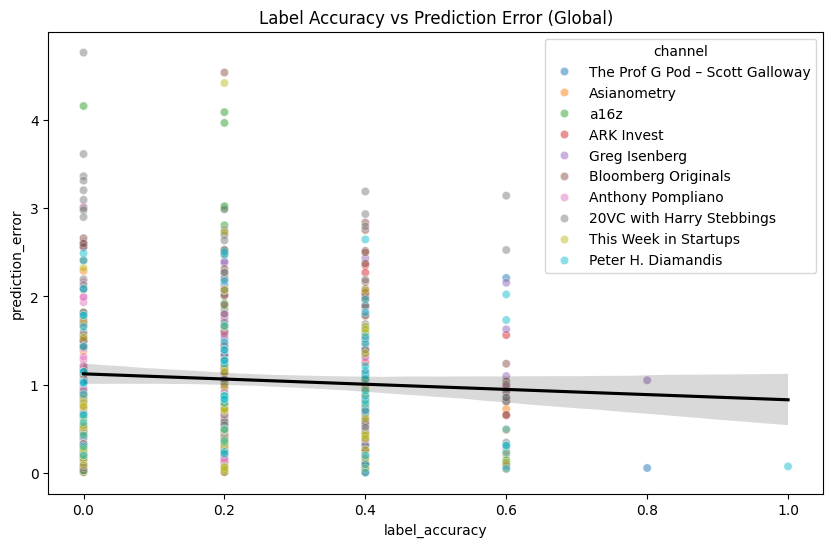

/tmp/ipykernel_3461/1399794987.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  channel_metrics = df_analysis.groupby('channel').apply(lambda x: pd.Series({


<Figure size 1200x600 with 0 Axes>

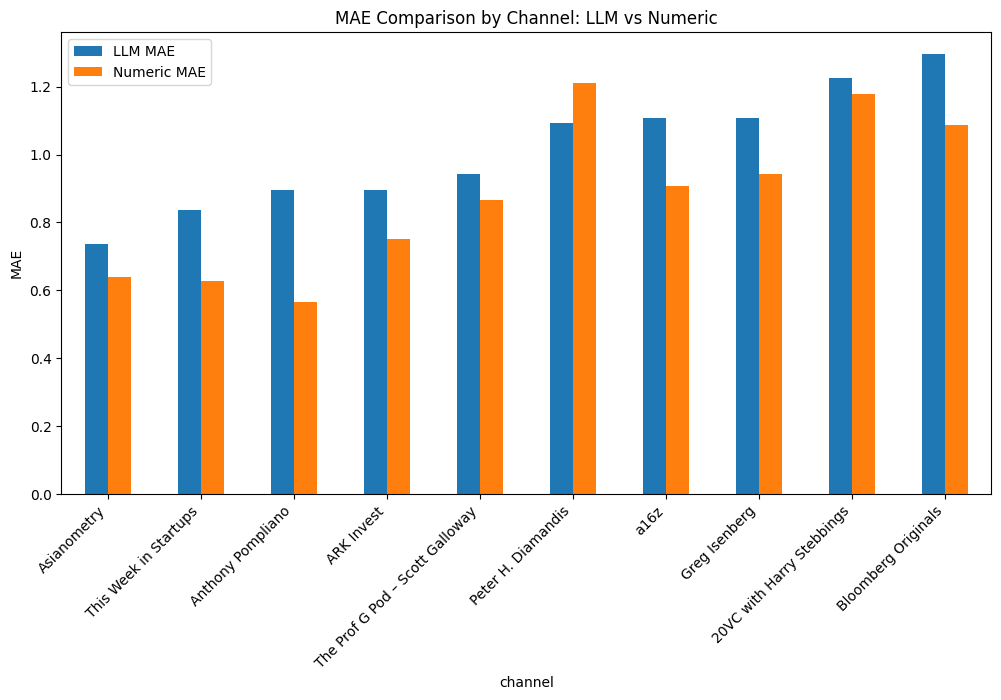

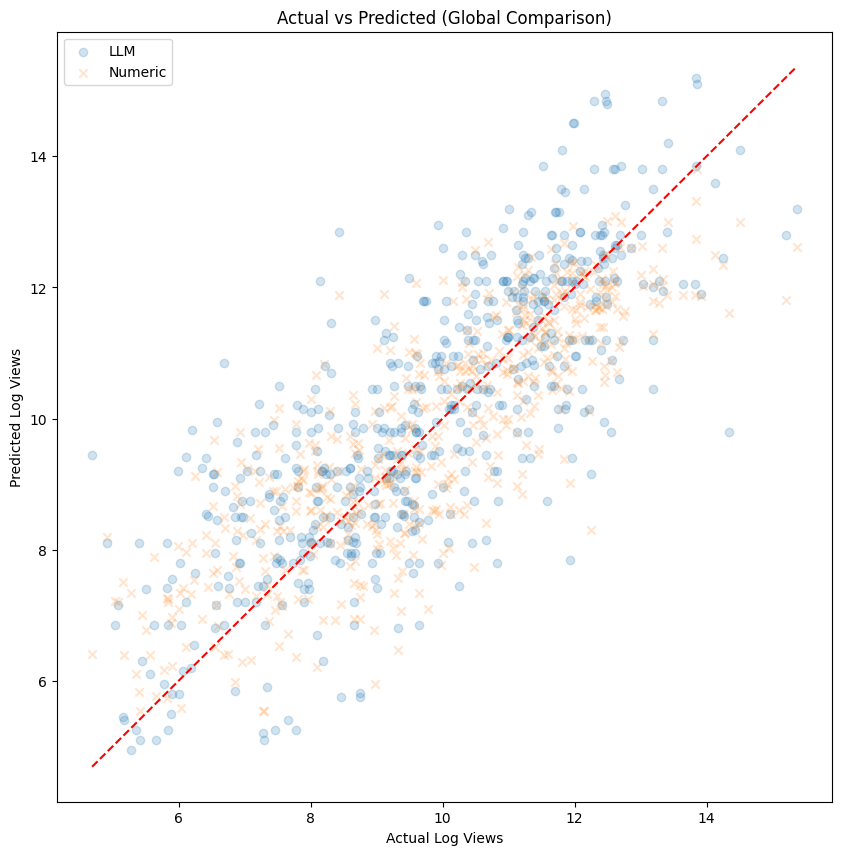

In [8]:
if not df_analysis.empty:
    # Label Accuracy vs Prediction Error
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_analysis, x='label_accuracy', y='prediction_error', hue='channel', alpha=0.5)
    sns.regplot(data=df_analysis, x='label_accuracy', y='prediction_error', scatter=False, color='black')
    plt.title("Label Accuracy vs Prediction Error (Global)")
    plt.show()

    # MAE Comparison
    plt.figure(figsize=(12, 6))
    channel_metrics = df_analysis.groupby('channel').apply(lambda x: pd.Series({
        'LLM MAE': mean_absolute_error(x['actual_log_views'], x['predicted_log_views']),
        'Numeric MAE': mean_absolute_error(x['actual_log_views'], x['numeric_prediction'])
    })).sort_values('LLM MAE')
    channel_metrics.plot(kind='bar', figsize=(12,6))
    plt.title("MAE Comparison by Channel: LLM vs Numeric")
    plt.ylabel("MAE")
    plt.xticks(rotation=45, ha='right')
    plt.show()

    # Actual vs Predicted
    plt.figure(figsize=(10, 10))
    plt.scatter(df_analysis['actual_log_views'], df_analysis['predicted_log_views'], alpha=0.2, label='LLM')
    plt.scatter(df_analysis['actual_log_views'], df_analysis['numeric_prediction'], alpha=0.2, label='Numeric', marker='x')
    plt.plot([df_analysis['actual_log_views'].min(), df_analysis['actual_log_views'].max()],
             [df_analysis['actual_log_views'].min(), df_analysis['actual_log_views'].max()], 'r--')
    plt.xlabel("Actual Log Views")
    plt.ylabel("Predicted Log Views")
    plt.legend()
    plt.title("Actual vs Predicted (Global Comparison)")
    plt.show()
else:
    print("No valid results to visualize.")

## 8. Export Results

In [9]:
with open(OUTPUT_FILE, 'w') as f:
    json.dump(all_results, f, indent=4)
print(f"Results exported to {OUTPUT_FILE}")

Results exported to /content/drive/MyDrive/numeric_inference_outputs/feature_evaluation_results.json
